In [1]:
%%capture
%run ./Image_processing_fundamentals_pt3.ipynb

In [2]:
# All steps above combined into one function

def segment_bacteria(img_ecoli, sigma=3, min_size=50, dilation_radius=8, erosion_radius=4):
    '''
    Segment individual bacteria from a (bright bacteria, dark background) image.
    Returns a labeled mask (0 = background, 1..N = individual bacteria).
    '''

    # Laplacian of Gaussian
    img_ecoli_gauss = sk.filters.gaussian(img_ecoli, sigma=sigma)
    edges_log = sk.filters.laplace(img_ecoli_gauss)

    # Edge pixels: positive and negative values close
    edges_min = ndimage.minimum_filter(edges_log, footprint=sk.morphology.disk(1))
    edges_pos = ndimage.maximum_filter(edges_log, footprint=sk.morphology.disk(1))
    img_edges = np.logical_and(edges_min < 0, edges_pos > 0)

    # Whole-colony mask (triangle threshold), filtered and enlarged
    mask_ecoli_triangle = img_ecoli > sk.filters.threshold_triangle(img_ecoli)
    mask_ecoli_triangle_filtered = \
        sk.morphology.remove_small_objects(mask_ecoli_triangle, min_size=min_size)
    mask_ecoli_triangle_filtered = \
        sk.morphology.dilation(mask_ecoli_triangle_filtered, footprint=sk.morphology.disk(dilation_radius))

    # Only keep edges within colony, and fill outlines
    img_edges_foreground = np.logical_and(img_edges, mask_ecoli_triangle_filtered)
    img_edges_filled = ndimage.binary_fill_holes(img_edges_foreground)

    # Seeds: eroded & labeled mask
    mask_ecoli_log_eroded = \
        sk.morphology.erosion(img_edges_filled, footprint=sk.morphology.disk(erosion_radius))
    mask_bacteria_slim_labeled = sk.measure.label(mask_ecoli_log_eroded)

    # Watershed to separate touching bacteria
    mask_bacteria_combined = \
        sk.segmentation.watershed(
            -1*img_edges_filled,
            markers=mask_bacteria_slim_labeled,
            mask=img_edges_filled
        )

    return mask_bacteria_combined

/var/folders/8w/2thz_cgn3xn13rhrxb2dvb5w0000gn/T/ipykernel_16814/531234188.py:21: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  sk.morphology.remove_small_objects(mask_ecoli_triangle, min_size=min_size)


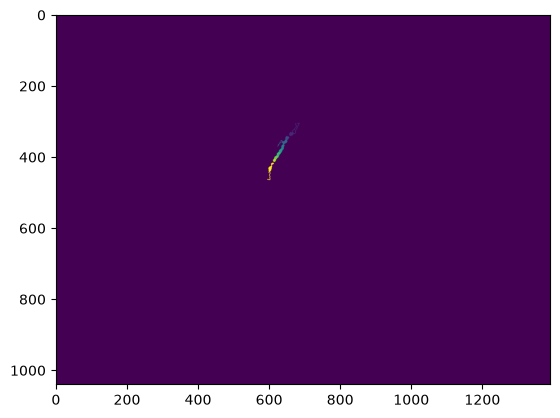

In [3]:
test_img = tiff.imread("/Users/m.wehrens/Data_notbacked/2025_Py-Image-workshop_Filamentation-example-data/rawdata/images_subset/pos3crop-p-2-901.tif")

_=plt.imshow(segment_bacteria(test_img))

## Doesn't work on all frames

Due to issues regarding background etc.